In [1]:
# Notebook: Festival Lineup Analysis
#
# Analyses the artist lineups of festivals (e.g. Paleo, Montreux Jazz)
# through the lens of Piki user data:
#
#   1. Lineup overview — Piki scores, ratings volume, genres
#   2. Artist performance — liked/superlike rates, best songs
#   3. Audience fit — how well the lineup maps to Piki user taste
#   4. Artist similarity heatmap — which artists go well together
#   5. Best pairings — top co-appealing artist pairs on the lineup

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.cluster.hierarchy import linkage, dendrogram
%matplotlib inline

%run db.py

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
# Set the festival venue name and (optionally) a date filter.
# Venue names in the shows table: 'Paleo', 'Montreux'
VENUE      = 'Paleo'
DATE_FROM  = '2026-01-01'   # set to None to include all years
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
def get_festival_lineup(venue, date_from=None, min_ratings=0):
    """
    Load the festival lineup from the shows table and enrich each artist
    with Piki score, liked/superlike rates, genre, and Spotify followers.

    Returns a DataFrame sorted by piki_score descending.
    """
    date_clause = f"AND s.date >= '{date_from}'" if date_from else ''

    sql = '''
        SELECT
            a.id                                                            AS artist_id,
            a.name                                                          AS artist,
            s.date,
            MAX(ag.genre)                                                   AS genre,
            MAX(a.num_fans)                                                 AS spotify_followers,
            MAX(a.pop_decile)                                               AS pop_decile,
            ROUND(MAX(ps.piki_score), 1)                                    AS piki_score,
            SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes)         AS total_ratings,
            ROUND(
                SUM(ps.num_likes + ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                            AS liked_rate,
            ROUND(
                SUM(ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                            AS superliked_rate
        FROM shows s
        INNER JOIN artists a    ON s.artist_id  = a.id
        LEFT  JOIN piki_score ps ON a.id         = ps.artist_id
        LEFT  JOIN artist_genre ag ON a.id       = ag.artist_id
        WHERE s.venue = '%s'
          %s
        GROUP BY a.id, a.name, s.date
        HAVING total_ratings >= %s OR total_ratings IS NULL
        ORDER BY piki_score DESC
    ''' % (venue.replace("'", "\\'"), date_clause, min_ratings)

    df = pd.DataFrame(DB.fetch(sql))
    if df.empty:
        print(f"No lineup found for venue='{venue}'")
        return df
    for col in ['piki_score', 'liked_rate', 'superliked_rate']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['total_ratings'] = pd.to_numeric(df['total_ratings'], errors='coerce').fillna(0).astype(int)
    print(f"Loaded {len(df)} artists for {venue}")
    return df

lineup = get_festival_lineup(VENUE, date_from=DATE_FROM, min_ratings=0)
lineup.head(20)

Loaded 72 artists for Paleo


,artist_id,artist,date,genre,spotify_followers,pop_decile,piki_score,total_ratings,liked_rate,superliked_rate
0,25,The Cure,2026-07-21,rock,10606318.0,75,98.0,5573,0.604,0.148
1,8598,Lorde,2026-07-21,pop,16521815.0,76,97.0,4979,0.609,0.109
2,1138255,Joshua Idehen,2026-07-21,None,30505.0,41,97.0,23,0.783,0.087
3,511578,Sylvie Kreusch,2026-07-21,pop,161695.0,40,96.0,11,0.818,0.273
4,190,Gorillaz,2026-07-21,alt,15767667.0,79,96.0,8136,0.642,0.152
5,423,Katy Perry,2026-07-21,pop,40753486.0,84,96.0,4448,0.603,0.120
6,590673,KomPROmaT,2026-07-21,indie pop,117500.0,35,96.0,216,0.523,0.204
7,14400,Roni Size,2026-07-21,electronic,226396.0,41,95.0,77,0.442,0.078
8,9613,Asaf Avidan,2026-07-21,folk,1585476.0,58,94.0,136,0.485,0.029
9,4505,Keny Arkana,2026-07-21,hip hop,158312.0,46,94.0,23,0.478,0.043


In [4]:
# ── Overview stats ────────────────────────────────────────────────────────────
rated = lineup[lineup['total_ratings'] > 0]
print(f"{'='*50}")
print(f"  {VENUE} Festival Lineup")
print(f"{'='*50}")
print(f"  Total artists        : {len(lineup)}")
print(f"  Artists with ratings : {len(rated)}")
print(f"  Avg Piki score       : {rated['piki_score'].mean():.1f}")
print(f"  Avg liked rate       : {rated['liked_rate'].mean():.1%}")
print(f"  Avg superlike rate   : {rated['superliked_rate'].mean():.1%}")
print(f"  Total ratings        : {lineup['total_ratings'].sum():,}")

  Paleo Festival Lineup
  Total artists        : 72
  Artists with ratings : 47
  Avg Piki score       : 73.9
  Avg liked rate       : 37.3%
  Avg superlike rate   : 5.7%
  Total ratings        : 33,110


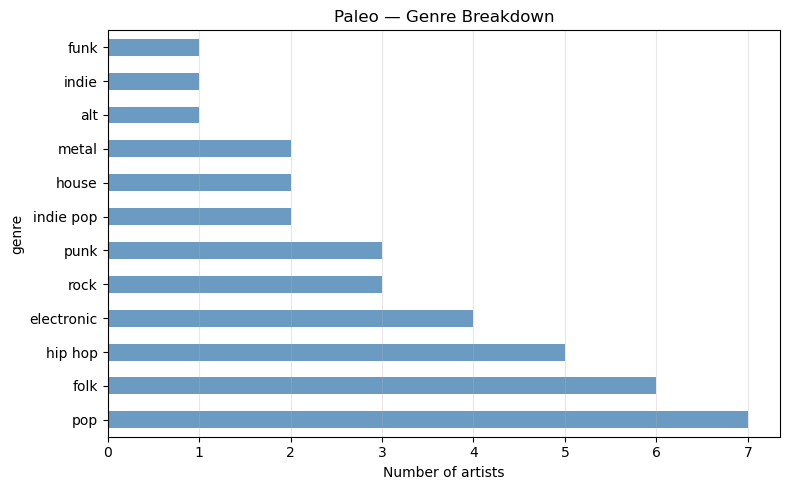

In [5]:
# ── Genre breakdown ────────────────────────────────────────────────────────────
genre_counts = lineup['genre'].value_counts().dropna().head(12)

fig, ax = plt.subplots(figsize=(8, 5))
genre_counts.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Number of artists')
ax.set_title(f'{VENUE} — Genre Breakdown')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

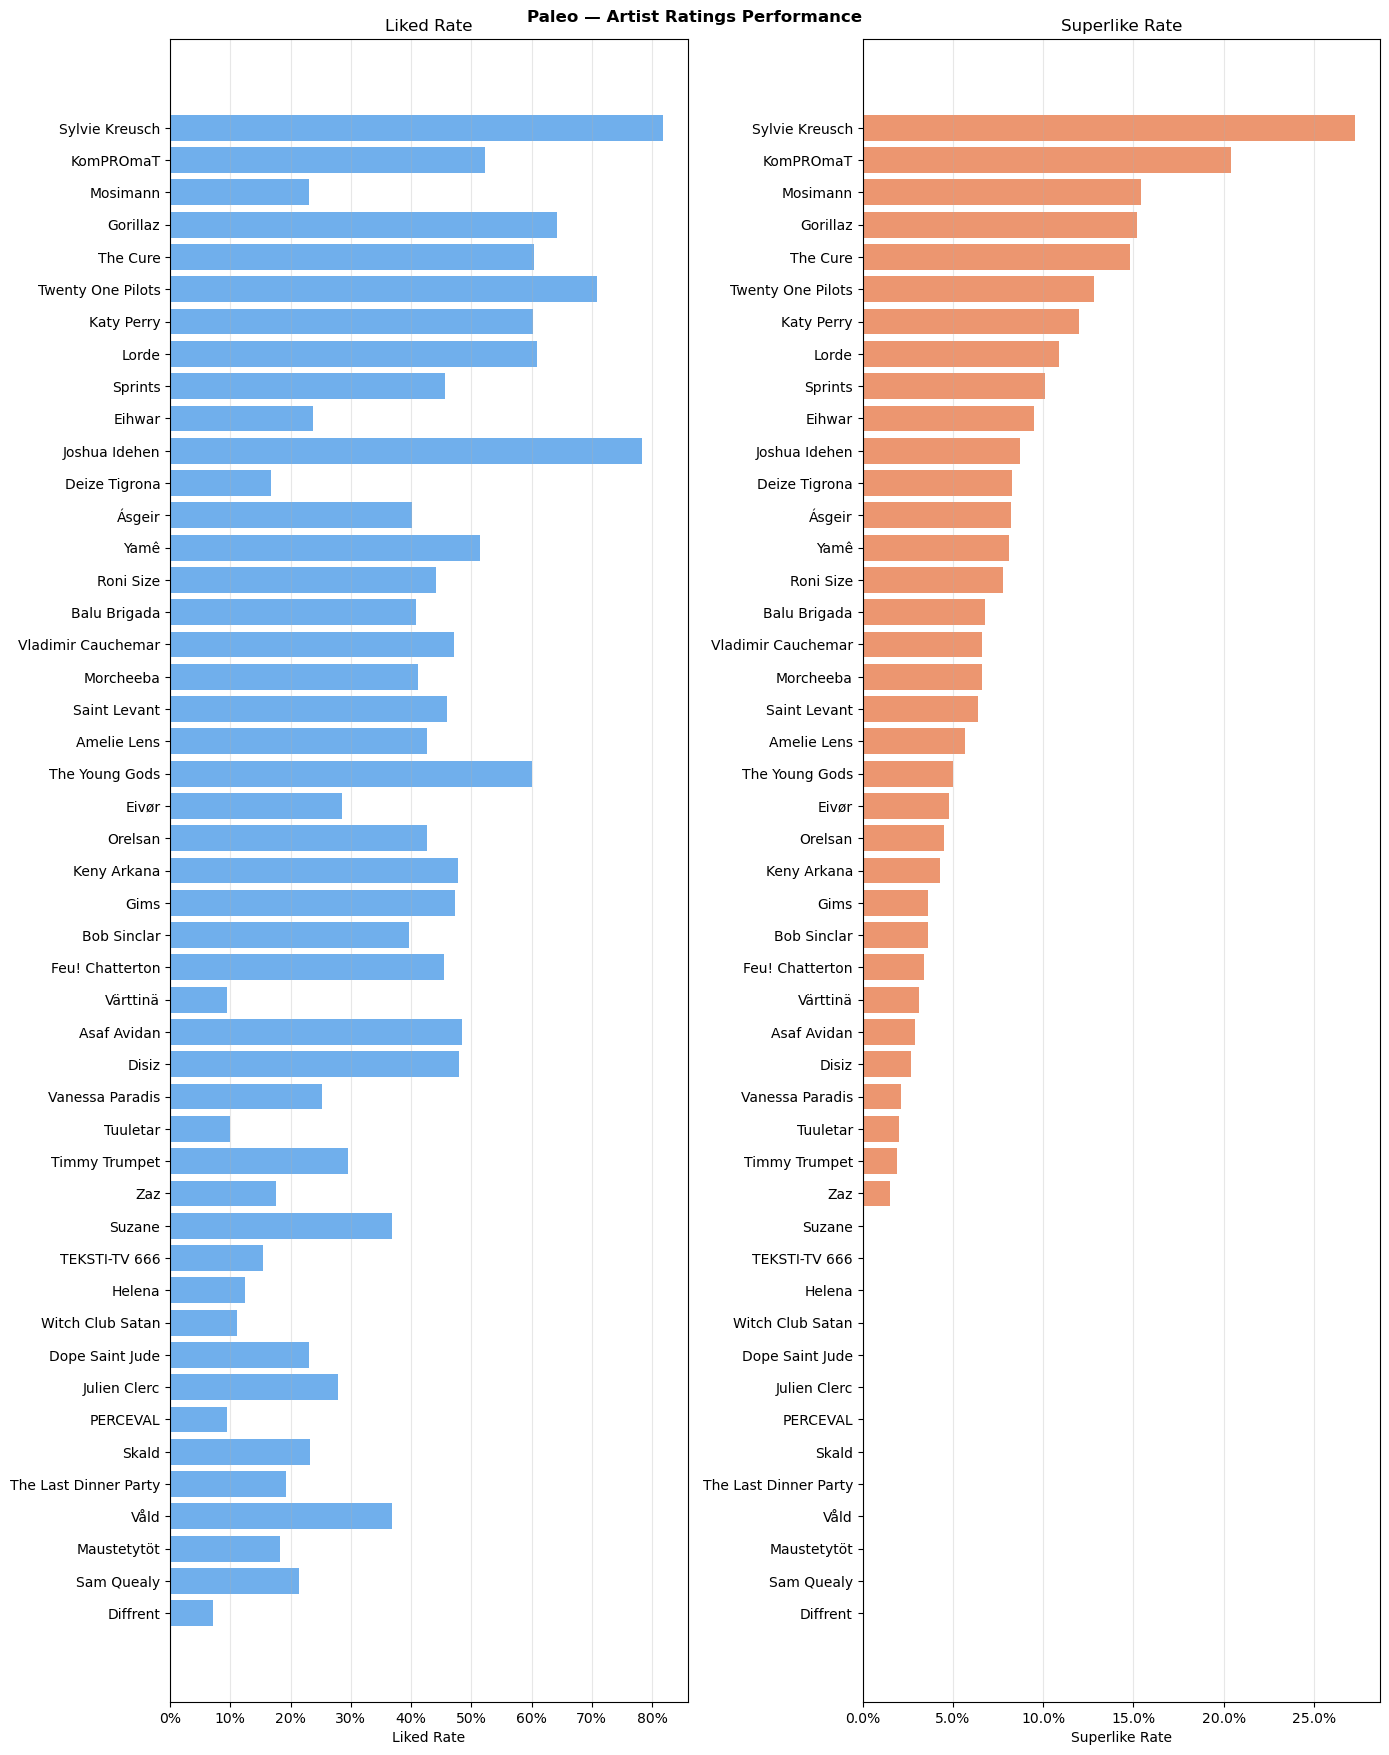

In [6]:
# ── Artist performance chart ──────────────────────────────────────────────────
# Show liked and superlike rates for each artist with sufficient data.
plot_df = rated.dropna(subset=['liked_rate', 'superliked_rate'])\
               .sort_values('superliked_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(plot_df) * 0.38)))

for ax, col, color, label in [
    (axes[0], 'liked_rate',      '#4C9BE8', 'Liked Rate'),
    (axes[1], 'superliked_rate', '#E87C4C', 'Superlike Rate'),
]:
    ax.barh(plot_df['artist'], plot_df[col], color=color, alpha=0.8)
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'{VENUE} — Artist Ratings Performance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Best songs per festival artist ────────────────────────────────────────────
def get_best_songs_for_artists(artist_ids, top_n=1):
    """
    Return the top_n highest-scored songs for each artist_id.
    """
    ids = ','.join(str(i) for i in artist_ids)
    sql = '''
        SELECT
            a.name  AS artist,
            c.title AS song,
            ps.piki_score,
            ps.num_likes,
            ps.num_superlikes,
            ps.num_dislikes,
            (ps.num_likes + ps.num_superlikes + ps.num_dislikes) AS total_ratings
        FROM piki_score ps
        INNER JOIN catalog c ON ps.song_id  = c.id
        INNER JOIN artists a ON c.artist_id = a.id
        WHERE a.id IN (%s)
        ORDER BY a.name, ps.piki_score DESC
    ''' % ids
    df = pd.DataFrame(DB.fetch(sql))
    if df.empty:
        return df
    return df.groupby('artist').head(top_n).reset_index(drop=True)

artist_ids = lineup[lineup['total_ratings'] > 0]['artist_id'].tolist()
best_songs = get_best_songs_for_artists(artist_ids, top_n=1)
best_songs.sort_values('piki_score', ascending=False).head(20)

,artist,song,piki_score,num_likes,num_superlikes,num_dislikes,total_ratings
34,The Cure,Close to Me,98.0,56,33,64,153
20,Lorde,Everybody Wants To Rule the World (OST Dracula...,97.0,6,3,2,11
15,Joshua Idehen,Illegal Hit - Edit,97.0,16,2,5,23
17,Katy Perry,Who Am I Living For?,96.0,3,2,5,10
13,Gorillaz,Orchestral Intro (feat. Sinfonia ViVA),96.0,9,2,5,16
32,Sylvie Kreusch,Dangerous,96.0,6,3,2,11
19,KomPROmaT,Herztod,96.0,2,3,4,9
26,Roni Size,All The Crew Big Up - 95 Relick,95.0,9,0,2,11
1,Asaf Avidan,My Tunnels Are Long and Dark These Days,94.0,21,3,12,36
18,Keny Arkana,Eh Connard,94.0,5,1,4,10


In [8]:
# ── Similarity heatmap helpers (adapted from 2-similar-artists.ipynb) ─────────
def get_most_rated_song(artist_id):
    """Return the song_id with the most total ratings for a given artist."""
    sql = '''
        SELECT song_id, MAX(title) AS title, COUNT(*) AS cnt
        FROM (
            SELECT us.song_id, c.title
            FROM user_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
            UNION ALL
            SELECT us.song_id, c.title
            FROM unliked_songs us
            INNER JOIN catalog c ON us.song_id = c.id
            WHERE c.artist_id = %s
        ) t
        GROUP BY song_id
        ORDER BY cnt DESC
        LIMIT 1
    ''' % (artist_id, artist_id)
    rows = DB.fetch(sql)
    return rows[0] if rows else None


def get_song_agreement(song_id_a, song_id_b):
    """
    P(users agree) between two songs — fraction of shared users who
    gave the same rating (both liked or both disliked).
    """
    sql = '''
        SELECT
            COUNT(*)                          AS shared_users,
            AVG(IF(a.liked = b.liked, 1, 0))  AS p_agreement
        FROM (
            SELECT user_id, 1 AS liked FROM user_songs    WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) a
        INNER JOIN (
            SELECT user_id, 1 AS liked FROM user_songs    WHERE song_id = %s
            UNION ALL
            SELECT user_id, 0 AS liked FROM unliked_songs WHERE song_id = %s
        ) b ON a.user_id = b.user_id
    ''' % (song_id_a, song_id_a, song_id_b, song_id_b)
    return DB.fetch(sql)[0]

Loaded 51 artists for Paleo
Gorillaz                       → Feel Good Inc. (n=2353)
Twenty One Pilots              → Stressed Out (n=682)
The Cure                       → Just Like Heaven (n=1208)
Lorde                          → Royals (n=1425)
Katy Perry                     → I Kissed a Girl (n=476)
Morcheeba                      → The Sea (n=130)
Ásgeir                         → Nothing (n=102)
Orelsan                        → Basique (n=150)
KomPROmaT                      → Einfach da sein (n=193)
Sprints                        → Little Fix (n=81)
Vanessa Paradis                → Joe le taxi (n=19)
Amelie Lens                    → Purge (n=67)
Zaz                            → Je veux (n=46)
Asaf Avidan                    → My Tunnels Are Long and Dark These Days (n=36)
Suzane                         → Quatre coins du globe (n=21)
Bob Sinclar                    → World Hold On - FISHER Rework (n=39)
Saint Levant                   → Very Few Friends (n=54)
Vladimir Cauchemar        

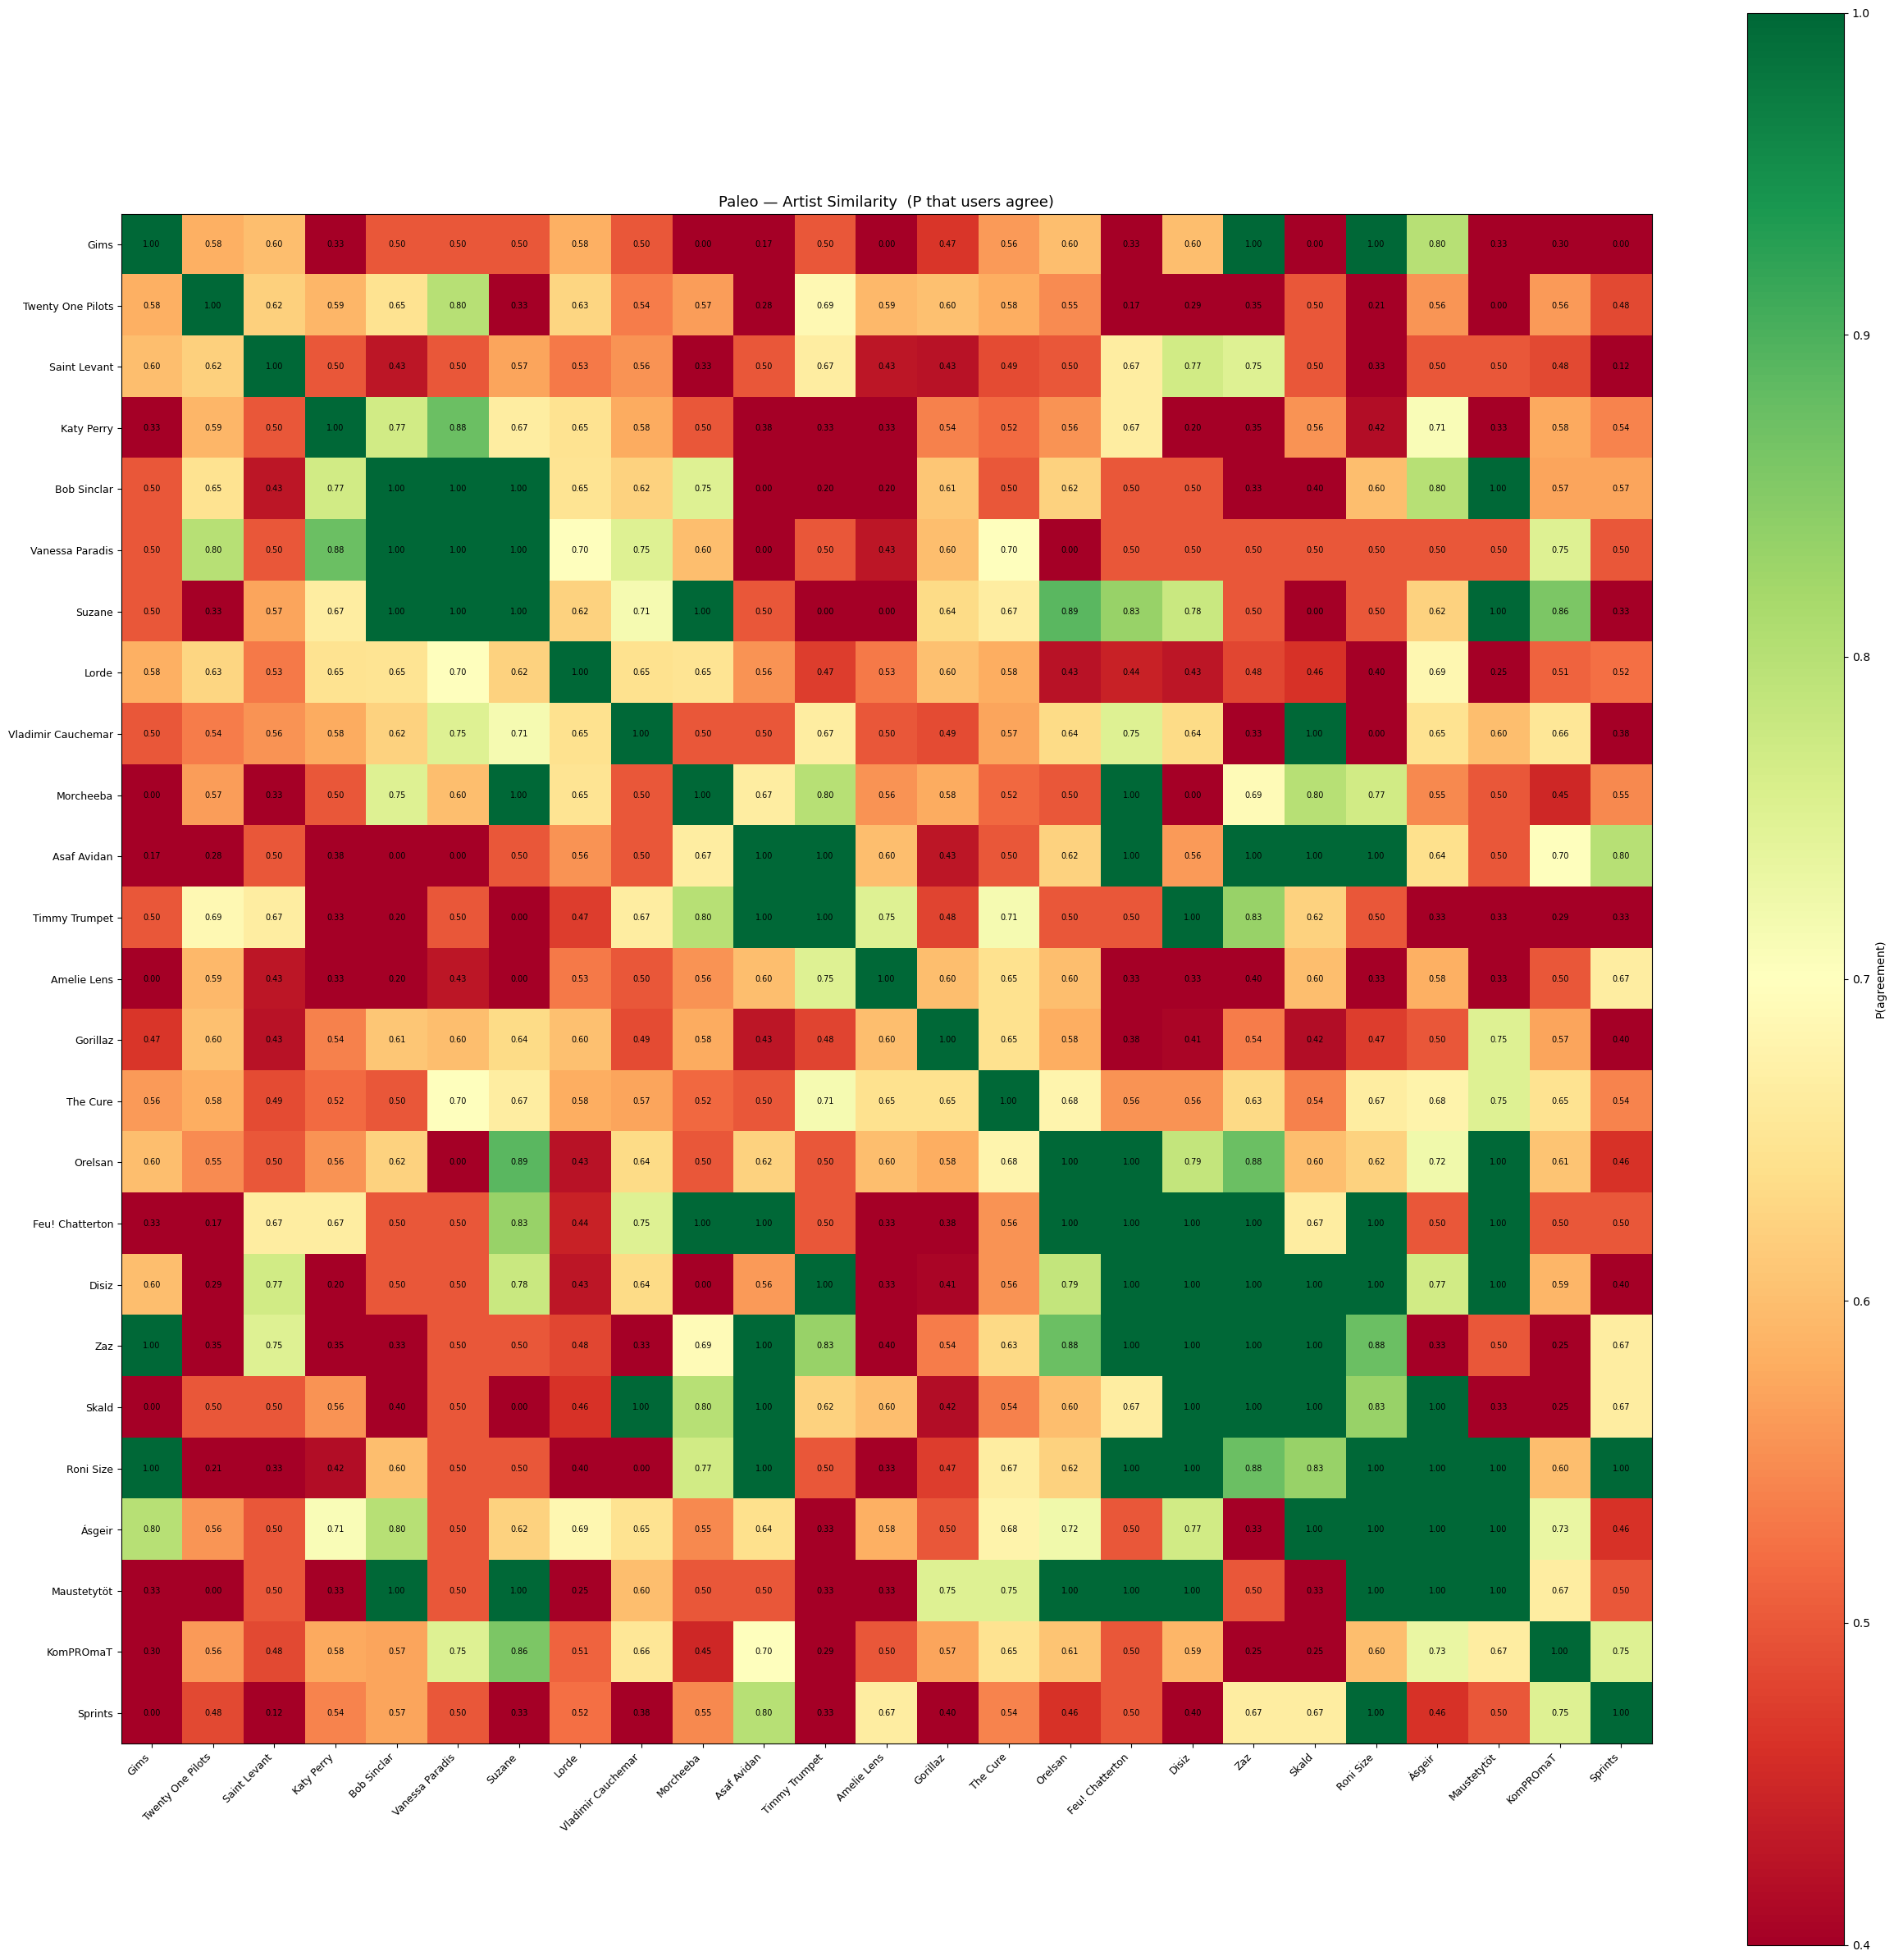

In [9]:
def plot_festival_heatmap(venue, date_from=None, min_ratings=50, max_artists=25):
    """
    Compute a pairwise artist-similarity heatmap for a festival lineup.

    Only artists with >= min_ratings are included.  Artists are limited
    to max_artists (highest-rated) to keep the chart readable.  Rows/columns
    are reordered by hierarchical clustering so similar artists sit together.
    """
    lp = get_festival_lineup(venue, date_from=date_from, min_ratings=min_ratings)
    lp = lp.dropna(subset=['piki_score'])\
            .sort_values('total_ratings', ascending=False)\
            .head(max_artists)

    if lp.empty:
        print("Not enough artists with ratings data.")
        return

    # Fetch most-rated song per artist
    songs = []
    for _, row in lp.iterrows():
        song = get_most_rated_song(row['artist_id'])
        if song:
            songs.append({'artist': row['artist'], 'artist_id': row['artist_id'],
                          'song_id': song['song_id'], 'title': song['title']})
            print(f"{row['artist']:30s} → {song['title']} (n={song['cnt']})")

    n = len(songs)
    if n < 2:
        print("Need at least 2 artists with song data.")
        return

    # Pairwise agreement matrix
    sim = np.zeros((n, n))
    for i in range(n):
        sim[i, i] = 1.0
        for j in range(i + 1, n):
            result = get_song_agreement(songs[i]['song_id'], songs[j]['song_id'])
            p = float(result['p_agreement']) if result['shared_users'] else 0.5
            sim[i, j] = p
            sim[j, i] = p

    # Cluster by similarity
    labels = [s['artist'] for s in songs]
    if n > 2:
        dist = 1 - sim
        np.fill_diagonal(dist, 0)
        Z = linkage(dist[np.triu_indices(n, k=1)], method='ward')
        order = dendrogram(Z, no_plot=True)['leaves']
        sim    = sim[np.ix_(order, order)]
        labels = [labels[i] for i in order]

    # Plot
    fig, ax = plt.subplots(figsize=(max(9, n), max(7, n - 1)))
    im = ax.imshow(sim, vmin=0.4, vmax=1.0, cmap='RdYlGn')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')
    plt.colorbar(im, ax=ax, label='P(agreement)')
    ax.set_title(f'{venue} — Artist Similarity  (P that users agree)', fontsize=13)
    plt.tight_layout()
    plt.show()

    return sim, labels

sim, labels = plot_festival_heatmap(VENUE, date_from=DATE_FROM, min_ratings=50)

In [10]:
# ── Best pairings ─────────────────────────────────────────────────────────────
# Rank every artist pair by P(agreement) to surface the strongest co-appeal.
if sim is not None and labels is not None:
    n = len(labels)
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append({'artist_a': labels[i], 'artist_b': labels[j],
                          'p_agreement': round(sim[i, j], 3)})

    pairs_df = pd.DataFrame(pairs).sort_values('p_agreement', ascending=False)
    print(f"Top 20 most compatible artist pairs at {VENUE}:")
    pairs_df.head(20)

Top 20 most compatible artist pairs at Paleo:
